# 01 - Meteogram quicklook: NW & NF

Time–height pcolormesh of bulk droplet (NW) and ice-crystal (NF) number
concentrations for every meteogram station in the Zarr store.

Layout: **n_stations rows x 2 columns** (left = NW, right = NF).

In [1]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: 22182-mbp-2.local
is_server: False


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from utilities.plotting import get_extpar_data

## Configuration

In [3]:
cs_run = "cs-eriswil__20260211_194236"

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
    extpar_path = root / "COS_in" / "extPar_Eriswil_50x40.nc"
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run
    extpar_path = data_dir / "extPar_Eriswil_50x40.nc"

zarr_files = sorted(data_dir.glob("Meteogram_cs-eriswil__20260211_194236_nVar136_nMet3_nExp4.zarr"))
print(f"Available Zarr stores in {data_dir}:")
for z in zarr_files:
    print(f"  {z.name}")

# pick the store to plot (edit index or path as needed)
zarr_path = zarr_files[-1]
print(f"\nUsing: {zarr_path.name}")
print(f"ExtPar: {extpar_path.name}")

Available Zarr stores in /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260211_194236:
  Meteogram_cs-eriswil__20260211_194236_nVar136_nMet3_nExp4.zarr

Using: Meteogram_cs-eriswil__20260211_194236_nVar136_nMet3_nExp4.zarr
ExtPar: extPar_Eriswil_50x40.nc


In [4]:
# bin range for bulk integration (COSMO-SPECS cloud-droplet / ice-crystal range)
LBB = slice(30, 50)   # liquid bins
CBB = slice(30, 50)   # crystal bins

# experiment index to plot (pick one for the quicklook)
EXP_IDX = 0

## Load data

In [5]:
ds = xr.open_dataset(zarr_path, engine="zarr")
print("Sizes:", dict(ds.sizes))
print("Data vars:", list(ds.data_vars))

assert "NW" in ds.data_vars and "NF" in ds.data_vars, (
    f"Zarr store must contain NW and NF. Found: {list(ds.data_vars)}"
)

Sizes: {'bins_boundaries': 67, 'expname': 4, 'height_level': 20, 'height_level2': 21, 'bins': 66, 'station': 3, 'time': 4033}
Data vars: ['NF', 'NI', 'NINP', 'NW', 'PHL', 'PML', 'QC', 'QC_Sp', 'QF', 'QFA', 'QFS', 'QFW', 'QI', 'QI_Sp', 'QIA', 'QV', 'QV_Sp', 'QW', 'QWA', 'QWS', 'RGRENZ_left', 'RGRENZ_right', 'RHO', 'SUM_BREAN', 'SUM_BREAQ', 'SUM_CONDN', 'SUM_CONDNFROD', 'SUM_CONDQ', 'SUM_CONDQFROD', 'SUM_CONDQWFROD', 'SUM_deponf', 'SUM_depoqf', 'SUM_dnfmelt', 'SUM_dnwmelt', 'SUM_dqffrier', 'SUM_dqfmelt', 'SUM_dqfwmelt', 'SUM_dqwmelt', 'SUM_HOMN', 'SUM_HOMQ', 'SUM_IMMERN', 'SUM_IMMERQ', 'SUM_knf', 'SUM_KOLLN', 'SUM_KOLLN_INS', 'SUM_KOLLNFROD', 'SUM_KOLLNFROD_INS', 'SUM_KOLLNFRODI', 'SUM_KOLLNI', 'SUM_KOLLQ', 'SUM_KOLLQ_INS', 'SUM_KOLLQFROD', 'SUM_KOLLQFROD_INS', 'SUM_KOLLQFRODI', 'SUM_KOLLQI', 'SUM_kollqwf', 'SUM_kqf', 'SUM_kqwf', 'SUM_N_BREAN', 'SUM_N_BREAQ', 'SUM_N_CONDN', 'SUM_N_CONDNFROD', 'SUM_N_CONDQ', 'SUM_N_CONDQFROD', 'SUM_N_CONDQWFROD', 'SUM_N_deponf', 'SUM_N_depoqf', 'SUM_N_dnf

In [6]:
ds

<xarray.Dataset> Size: 30GB
Dimensions:              (bins_boundaries: 67, expname: 4, height_level: 20,
                          height_level2: 21, bins: 66, station: 3, time: 4033)
Coordinates: (12/14)
  * bins_boundaries      (bins_boundaries) int64 536B 0 1 2 3 4 ... 63 64 65 66
  * expname              (expname) <U14 224B '20260211194236' ... '2026021119...
  * height_level         (height_level) int64 160B 80 81 82 83 ... 96 97 98 99
  * height_level2        (height_level2) int64 168B 80 81 82 83 ... 97 98 99 100
    HHLd                 (height_level2) float32 84B ...
    HMLd                 (height_level) float32 80B ...
    ...                   ...
    radius_boundaries    (bins_boundaries) float64 536B ...
    radius_centers       (bins) float64 528B ...
  * station              (station) int32 12B 1 2 3
    station_lat          (station) float64 24B ...
    station_lon          (station) float64 24B ...
  * time                 (time) datetime64[ns] 32kB 2023-01-25T12:00:00 ... 2...
Dimensions without coordinates: bins
Data variables: (12/136)
    NF                   (expname, station, time, height_level, bins) float32 256MB ...
    NI                   (expname, station, time, height_level) float32 4MB ...
    NINP                 (expname, station, time, height_level) float32 4MB ...
    NW                   (expname, station, time, height_level, bins) float32 256MB ...
    PHL                  (expname, station, time, height_level2) float32 4MB ...
    PML                  (expname, station, time, height_level) float32 4MB ...
    ...                   ...
    TKE                  (expname, station, time, height_level2) float32 4MB ...
    U                    (expname, station, time, height_level) float32 4MB ...
    V                    (expname, station, time, height_level) float32 4MB ...
    VF                   (expname, station, time, height_level, bins) float32 256MB ...
    VW                   (expname, station, time, height_level, bins) float32 256MB ...
    W                    (expname, station, time, height_level2) float32 4MB ...

In [7]:
ds_exp = ds.isel(expname=EXP_IDX)

# bulk number concentration: sum over selected bin range
# (station, time, height_level)
nw_bulk = xr.where(ds_exp["NW"]>0, ds_exp["NW"], np.nan).isel(bins=LBB).sum(dim="bins") 
nf_bulk = xr.where(ds_exp["NF"]>0, ds_exp["NF"], np.nan).isel(bins=CBB).sum(dim="bins")

# convert mixing ratio (1/kg) → concentration (1/cm³) if RHO is available
if "RHO" in ds_exp.data_vars:
    rho = ds_exp["RHO"]
    nw_bulk = nw_bulk * rho * 1e-6
    nf_bulk = nf_bulk * rho * 1e-6
    unit = r"cm$^{-3}$"
else:
    unit = r"kg$^{-1}$"

height = ds_exp["HMLd"].values
time = ds_exp["time"].values
n_stations = ds_exp.sizes["station"]

print(f"Experiment: {ds.expname.values[EXP_IDX]}")
print(f"Stations: {n_stations}, time steps: {time.size}, height levels: {height.size}")

Experiment: 20260211194236
Stations: 3, time steps: 4033, height levels: 20


In [8]:
lat2D, lon2D, hsurf = get_extpar_data(str(extpar_path))
print(f"ExtPar grid: {lat2D.shape}, height range: {hsurf.min():.0f}–{hsurf.max():.0f} m")

ExtPar grid: (26, 36), height range: 597–1205 m


## Quicklook: time–height cross-sections

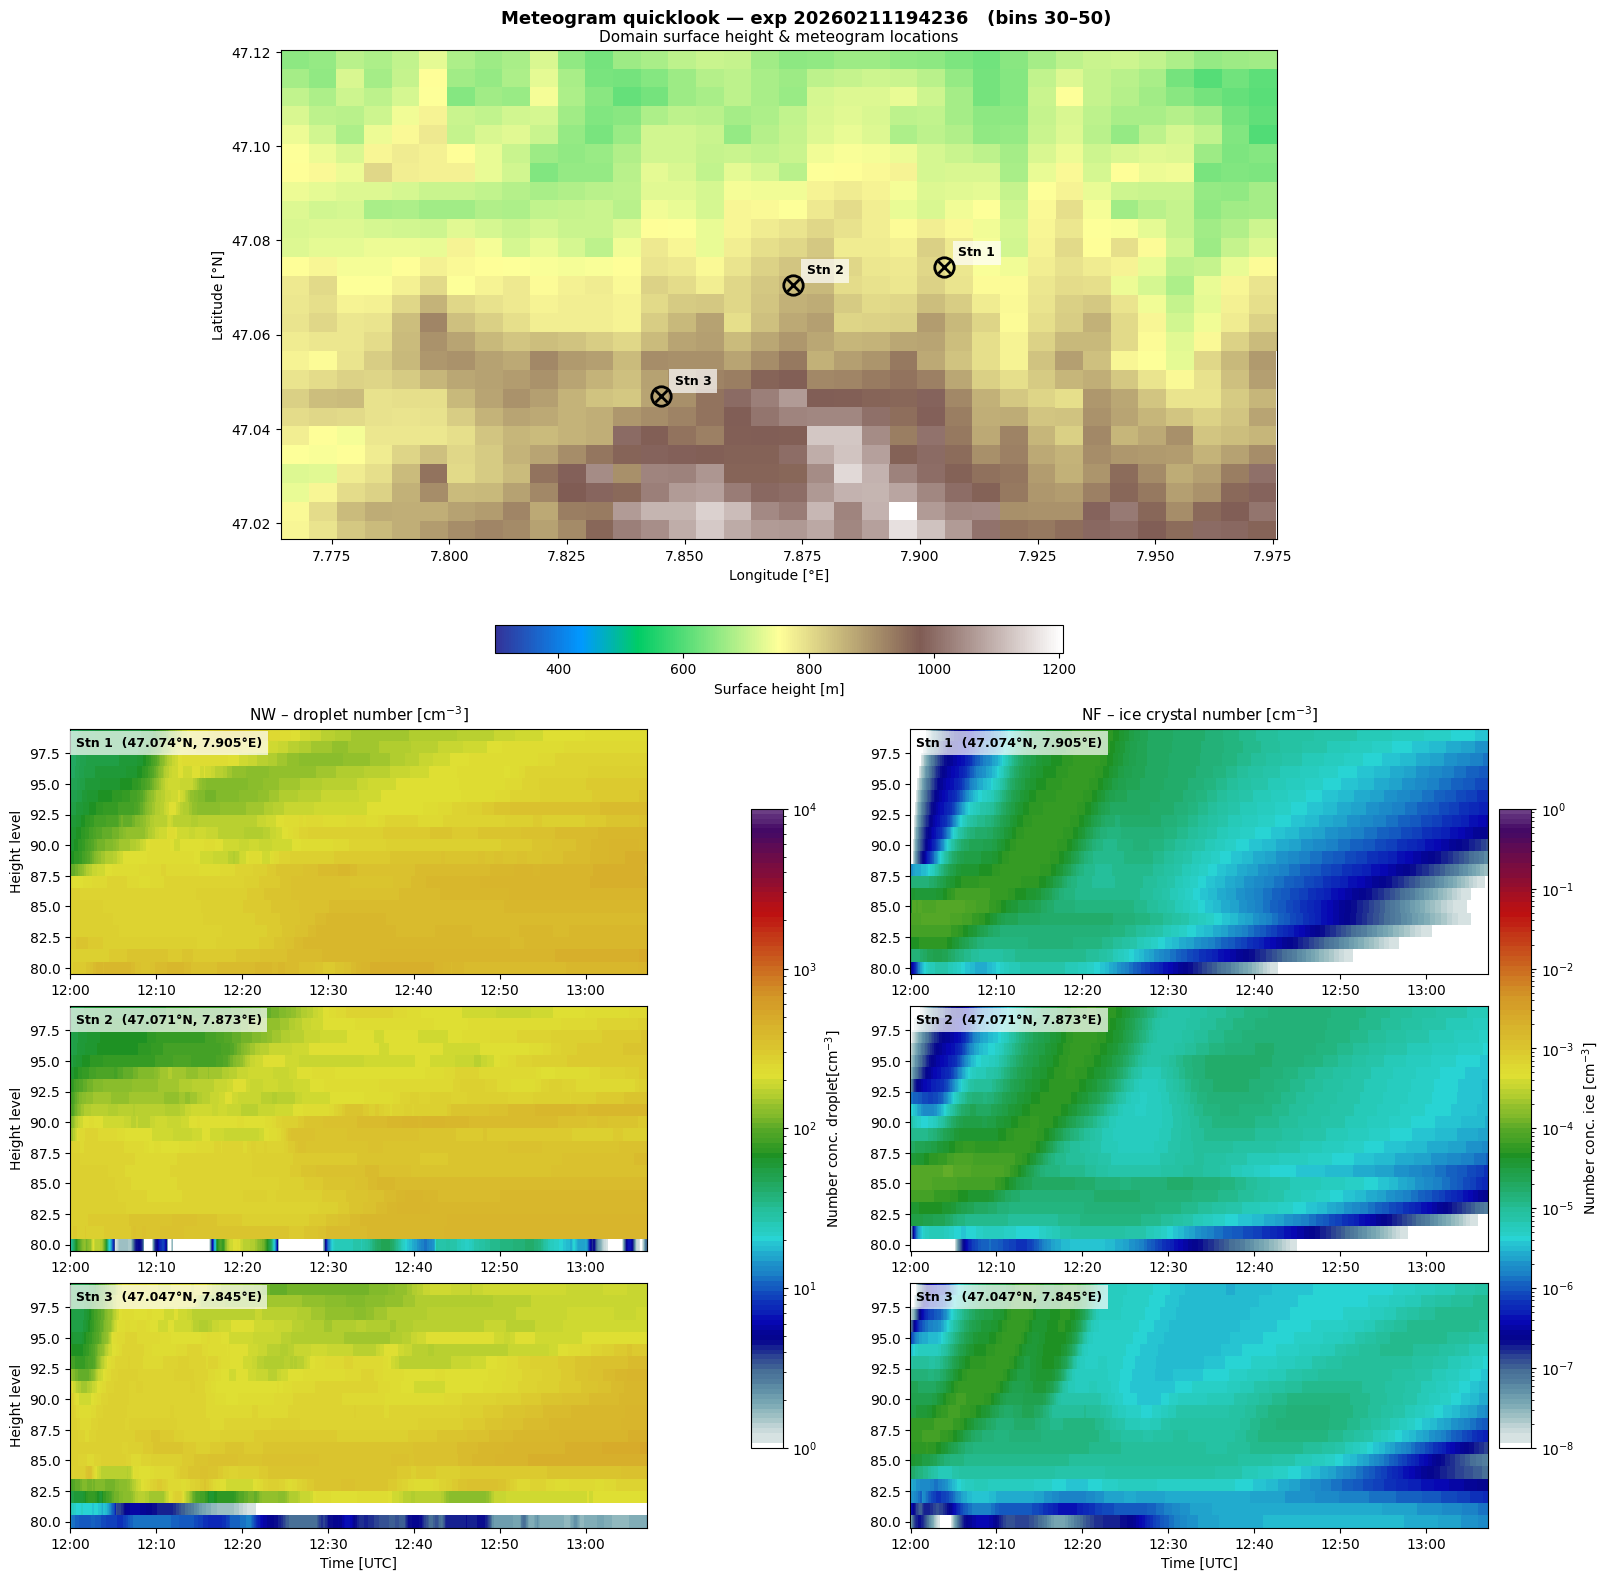

In [9]:

from utilities.plotting import create_new_jet3, create_fade_cmap, make_pastel

# Colormaps for plume-path (ice + transition + BkBl; soft for overlay)
new_jet4 = create_new_jet3(1024)
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)


fig = plt.figure(figsize=(16, 5 + 3.5 * n_stations), constrained_layout=True)
gs = fig.add_gridspec(nrows=1 + n_stations, ncols=2,
                      height_ratios=[2] + [1] * n_stations)

# ── Top panel: surface height + station locations (centered) ──
ax_map = fig.add_subplot(gs[0, :])
pm = ax_map.pcolormesh(lon2D, lat2D, hsurf, cmap="terrain", vmin=300, shading="auto")
fig.colorbar(pm, ax=ax_map, label="Surface height [m]",
             orientation="horizontal", shrink=0.4, pad=0.08)

for i in range(n_stations):
    slat = float(ds_exp.station_lat.values[i])
    slon = float(ds_exp.station_lon.values[i])
    sid = int(ds_exp.station.values[i])
    ax_map.plot(slon, slat, "o", ms=14, mfc="none", mec="k", mew=2, zorder=5)
    ax_map.plot(slon, slat, "x", ms=9, mew=2, color="k", zorder=6)
    ax_map.annotate(f"Stn {sid}", (slon, slat), textcoords="offset points",
                    xytext=(10, 8), fontsize=9, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax_map.set_xlabel("Longitude [°E]")
ax_map.set_ylabel("Latitude [°N]")
ax_map.set_title("Domain surface height & meteogram locations", fontsize=11)
ax_map.set_aspect("equal")
ax_map.set_anchor("C")

# ── NW / NF time–height panels ──
axes = np.empty((n_stations, 2), dtype=object)
for i in range(n_stations):
    for j in range(2):
        kw = {}
        if i > 0:
            kw["sharex"] = axes[0, j]
        if j > 0:
            kw["sharey"] = axes[i, 0]
        axes[i, j] = fig.add_subplot(gs[1 + i, j], **kw)

# shared colour limits from 2nd/98th percentile across NW and NF
vmin = min(float(nw_bulk.quantile(0.02)), float(nf_bulk.quantile(0.02)))
vmax = max(float(nw_bulk.quantile(0.98)), float(nf_bulk.quantile(0.98)))

plot_kw = dict(x="time", y="height_level", cmap=new_jet3_soft,
               add_colorbar=False, add_labels=False)

for i in range(n_stations):
    slat = float(ds_exp.station_lat.values[i])
    slon = float(ds_exp.station_lon.values[i])
    sid = int(ds_exp.station.values[i])
    label = f"Stn {sid}  ({slat:.3f}°N, {slon:.3f}°E)"

    pcm_nw = nw_bulk.isel(station=i).plot.pcolormesh(ax=axes[i, 0], norm=mcolors.LogNorm(vmin=1e0, vmax=1e4), **plot_kw)
    axes[i, 0].set_ylabel("Height level")
    axes[i, 0].text(0.01, 0.97, label, transform=axes[i, 0].transAxes,
                     va="top", fontsize=9, fontweight="bold",
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    pcm_nf = nf_bulk.isel(station=i).plot.pcolormesh(ax=axes[i, 1], norm=mcolors.LogNorm(vmin=1e-8, vmax=1e0), **plot_kw)
    axes[i, 1].text(0.01, 0.97, label, transform=axes[i, 1].transAxes,
                     va="top", fontsize=9, fontweight="bold",
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

axes[0, 0].set_title(f"NW – droplet number [{unit}]", fontsize=11)
axes[0, 1].set_title(f"NF – ice crystal number [{unit}]", fontsize=11)

for ax in axes[-1, :]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xlabel("Time [UTC]")

# single shared colorbar for all NW/NF panels
fig.colorbar(pcm_nw, ax=axes[:, 0], label=f"Number conc. droplet[{unit}]", shrink=0.8, pad=0.0)
fig.colorbar(pcm_nf, ax=axes[:, 1], label=f"Number conc. ice [{unit}]", shrink=0.8, pad=0.02)

fig.suptitle(
    f"Meteogram quicklook — exp {ds.expname.values[EXP_IDX]}   "
    f"(bins {LBB.start}–{LBB.stop})",
    fontsize=13, fontweight="bold", y=1.01,
)

plt.show()